In [1]:
import polars as pl

In [2]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes.parquet -o /home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes.parquet

Error: path "/home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes.parquet"
already exists but -f/--overwrite was not set


In [3]:
b2p = pl.scan_parquet('/home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes.parquet')
b2p.head().collect()

CHROM,POS,REF,ALT,SAMPLE,GT
str,i64,str,str,str,i8
"""chr10""",20020006,"""C""","""T""","""5317620""",1
"""chr10""",20020007,"""TTTTCTTGC""","""T""","""5546988""",1
"""chr10""",20020010,"""T""","""C""","""2793793""",1
"""chr10""",20020013,"""T""","""G""","""1314475""",1
"""chr10""",20020014,"""G""","""A""","""1722739""",1


In [4]:
(
    b2p
    .with_columns(
        pl.concat_str(
            [
                pl.col("CHROM"),
                pl.lit(":"),
                pl.col("POS").cast(pl.Utf8),
                pl.lit(":"),
                pl.col("REF"),
                pl.lit(":"),
                pl.col("ALT"),
            ]
        ).alias("ID")
    )
    .select(['ID'])
    .sink_parquet('/home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes_ids.parquet', engine='streaming')
)

## Get unique vars and MACs

In [1]:
import polars as pl
import matplotlib.pyplot as plt
from plotnine import *

In [2]:
var_ids = pl.scan_parquet('/home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes_ids.parquet')
var_ids.head().collect()

ID
str
"""chr10:20020006:C:T"""
"""chr10:20020007:TTTTCTTGC:T"""
"""chr10:20020010:T:C"""
"""chr10:20020013:T:G"""
"""chr10:20020014:G:A"""


In [3]:
unq_vars = (
    var_ids
    .group_by('ID')
    .agg(
        ac = pl.len()
    )
    .sort('ac')
    .collect(engine='streaming')
)

unq_vars

ID,ac
str,u64
"""chr10:20195167:A:G""",1
"""chr10:20195203:G:GC""",1
"""chr10:20195308:T:G""",1
"""chr10:20195547:T:C""",1
"""chr10:20195609:C:G""",1
…,…
"""chr13:52395015:G:A""",490541
"""chr14:78460482:C:A""",490541
"""chr1:225403733:T:C""",490541


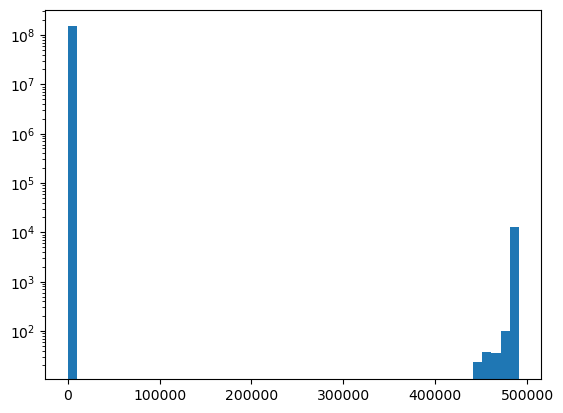

In [4]:
plt.hist(unq_vars['ac'], bins=50, log=True)
plt.show()

In [5]:
max_ac = unq_vars['ac'].max()
max_ac

490541

In [6]:
unq_vars = (
    unq_vars
    .with_columns(
        mac = (
            pl.when(pl.col('ac') > 400_000)
            .then(max_ac + 1 - pl.col('ac'))
            .otherwise(pl.col('ac'))
        )
    )
)

unq_vars

ID,ac,mac
str,u64,u64
"""chr10:20195167:A:G""",1,1
"""chr10:20195203:G:GC""",1,1
"""chr10:20195308:T:G""",1,1
"""chr10:20195547:T:C""",1,1
"""chr10:20195609:C:G""",1,1
…,…,…
"""chr13:52395015:G:A""",490541,1
"""chr14:78460482:C:A""",490541,1
"""chr1:225403733:T:C""",490541,1


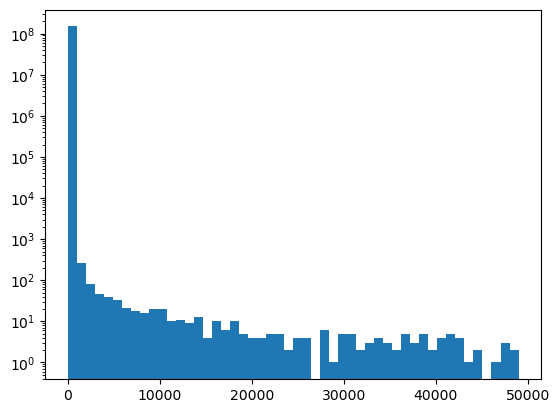

In [7]:
plt.hist(unq_vars['mac'], bins=50, log=True)
plt.show()

In [8]:
unq_vars.write_parquet('/home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes_unique_variants.parquet')

In [9]:
!dx upload /home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes_unique_variants.parquet --path project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/

[===========================================================>] Uploaded 811,257,895 of 811,257,895 bytes (100%) /home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes_unique_variants.parquet
ID                                file-J5QJy18Jg0y2X8bzqF0yqPyq
Class                             file
Project                           project-Gyp4fvjJg0yFZ374KvP9bGFJ
Folder                            /processed_data/wgs
Name                              qced_maf1e-3_loftee_olink_genes_unique_variants.parquet
State                             closing
Visibility                        visible
Types                             -
Properties                        -
Tags                              -
Outgoing links                    -
Created                           Fri Jan  9 10:57:09 2026
Created by                        shubhankar
 via the job                      job-J5QGvBjJg0y6y8z4VBQX0kY1
Last modified                     Fri Jan  9 10:57:12 2026
Media type                        
archi